### Imports

In [1]:
#Librerias para manipular datasets
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Contexto 

El cáncer de mama es un tipo de cáncer que se forma en las células de las mamas.
Después del cáncer de piel, el cáncer de mama es el tipo más común diagnosticado en mujeres en todo el
mundo.
El cáncer de mama se puede presentar tanto en hombres como en mujeres; sin embargo, es mucho más
común en las mujeres.
El considerable apoyo para la concientización y la financiación de investigaciones sobre el cáncer de mama
ha ayudado a crear avances en el diagnóstico y tratamiento de esta enfermedad.
Las tasas de supervivencia al cáncer de mama han aumentado y el número de muertes asociadas con esta enfermedad está disminuyendo constantemente, en
gran medida debido a factores como la detección temprana, un nuevo enfoque de tratamiento personalizado y una mejor comprensión de la enfermedad.


Este DataSet contiene las mediciones celulares a partir de imagenes digitalziadas de la masa de la mama

# Analisis del breast_cancer.csv

In [2]:
df_breast = pd.read_csv("data_sets/breast_cancer.csv")

#vista rapido de datos
df_breast.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Generenamos una copia para no alterar el contenido original

In [3]:
import shutil 

#Hacemos una copia de los datos
shutil.copy("data_sets/breast_cancer.csv", "copy/breast_can_copy.csv")

'copy/breast_can_copy.csv'

In [4]:
#Guardamos la copia en una variable
df_breast_copia = pd.read_csv("copy/breast_can_copy.csv")

df_breast_copia.tail()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
564,926424,1,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,1,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,1,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,1,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400
568,92751,0,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039


## Analisis exploratorio de los datos

Revisamos la cantidad la cantidad de filas y columnas

In [5]:
print(f"Cantidad de columnas {df_breast_copia.shape[1]}")
print(f"Cantidad de registros {df_breast_copia.shape[0]}")

Cantidad de columnas 32
Cantidad de registros 569


Revisamos los tipos de datos que contiene

In [6]:

df_breast_copia.dtypes

id                           int64
diagnosis                    int64
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concavity_worst     

In [7]:
print(f"Cantidad de floats {sum(df_breast_copia.dtypes == float)}")
print(f"Cantidad de Integers {sum(df_breast_copia.dtypes == int )}")
print(f"Cantidad de variables que no sean las dos anteriores: \n { sum(tipo != int and tipo != float and tipo != 'int64' and tipo != 'float64' for tipo in df_breast_copia.dtypes) }")

Cantidad de floats 30
Cantidad de Integers 2
Cantidad de variables que no sean las dos anteriores: 
 0


## Revision de nulos

In [8]:

conteo_nulos_por_columna = df_breast_copia.isnull().sum()
print("Valores nulos por columna:")
print(conteo_nulos_por_columna)

Valores nulos por columna:
id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


In [9]:

nulos_total = df_breast_copia.isnull().sum().sum()
print("Valores nulos por columna:")
print(nulos_total)

Valores nulos por columna:
0


Este DataSet no requiere tratamiento de nulos al no tener nulos

## Seleccion de datos

En esta seccion eliminaremos los datos los cuales no sean relevantex **Para saber si una paciente podria padecer de cancer** , Para ello se tomara en cuenta que una persona puede padecer de cancer de mama debido a lo siguietne :

- Un bulto o engrosamiento en la mama que se siente diferente del tejido que la rodea.
-  Cambio de tamaño, forma o aspecto de una mama.
-  Cambios en la piel que se encuentra sobre la mama, como formación de hoyuelos.
- La inversión reciente del pezón
- Descamación, desprendimiento de la piel, formación de costras y pelado del área pigmentada de la piel que rodea el pezón (areola) o la piel de
la mama
- Enrojecimiento o pequeños orificios en la piel que se encuentra sobre tu mama, como la piel de una naranja.

## Variable target : diagnosis

Con esta varibale como target podremos predecir el diagnostico de una persona, como primer paso eliminaremos la columna que a primera vista no aporta , el cual es el numero de identificacion del registro

In [10]:
#df_breast_copia["id"]
df_breast_copia = df_breast_copia.drop(columns=["id"])

df_breast_copia.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Id a sido eliminado exitosamente, tambien se detecto la **La columna unnamed** la cual no presenenta tener relevancia

In [11]:
if 'Unnamed: 32' in df_breast_copia.columns:
    df_breast_copia = df_breast_copia.drop(columns=['Unnamed: 32'])

if "Unnamed: 32" in df_breast_copia.index : 
    print("Aun esta la columna")
else : 
    print("Columna exitoasmente eliminada")

Columna exitoasmente eliminada


# Analasis de la variable target y su correlacion con las variables con las predictorias

Se procede a analizar la correlacion entre las varibales para decidir cuales son relevantes , con el fin de evitar problemas en el entrenamiento

### Analisis de destribucion de los valores en la columna diagnosis

Distribución porcentual de la variable 'diagnosis':
 - Benigno (0): 62.74%
 - Maligno (1): 37.26%


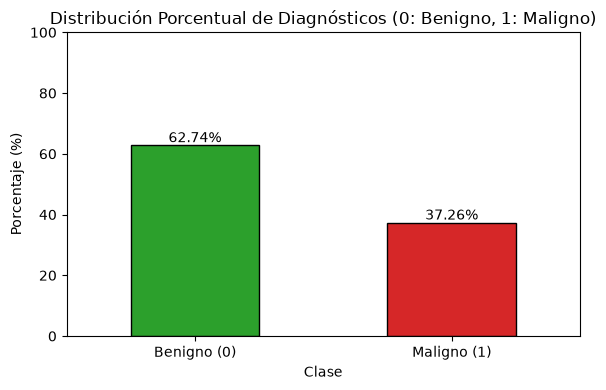

In [12]:
#Distribucion en procentaje
distribucion_porcentual = df_breast_copia['diagnosis'].value_counts(normalize=True) * 100

print("Distribución porcentual de la variable 'diagnosis':")
for clase, porcentaje in distribucion_porcentual.items():
    nombre_clase = "Maligno (1)" if clase == 1 else "Benigno (0)"
    print(f" - {nombre_clase}: {porcentaje:.2f}%")

# Grafico
plt.figure(figsize=(6, 4))
ax = distribucion_porcentual.plot(kind='bar', color=['#2ca02c', '#d62728'], edgecolor='black')
plt.title('Distribución Porcentual de Diagnósticos (0: Benigno, 1: Maligno)')
plt.xlabel('Clase')
plt.ylabel('Porcentaje (%)')
plt.xticks(ticks=[0, 1], labels=['Benigno (0)', 'Maligno (1)'], rotation=0)

# Anotación numérica sobre cada barra
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.ylim(0, 100)
plt.tight_layout()
plt.show()

Podemos ver como en los registros , mas de la mitad presentan ser 0 , osea benignos. Esto puede decirnos que el dataser tiene una carga hacia casos de diagnosis negativa (osea tumores no malignos)

### Analsisis de los tipos de datos en el data y correlacion con la variable target

Se logra ver que todas son de tipo numerico 

In [13]:
# Exponemos el nivel de correlación entre la columna a predecir ('diagnosis') y las predictoras
# Calculamos la correlación y la ordenamos de mayor a menor
correlacion_diagnosis = df_breast_copia.corr()['diagnosis'].sort_values(ascending=False)
#Se reguardan las columnas en correlacion_diagnosis para luego analizarlas


print("Correlación de las variables predictoras con 'diagnosis':\n")
print(correlacion_diagnosis)

Correlación de las variables predictoras con 'diagnosis':

diagnosis                  1.000000
concave points_worst       0.793566
perimeter_worst            0.782914
concave points_mean        0.776614
radius_worst               0.776454
perimeter_mean             0.742636
area_worst                 0.733825
radius_mean                0.730029
area_mean                  0.708984
concavity_mean             0.696360
concavity_worst            0.659610
compactness_mean           0.596534
compactness_worst          0.590998
radius_se                  0.567134
perimeter_se               0.556141
area_se                    0.548236
texture_worst              0.456903
smoothness_worst           0.421465
symmetry_worst             0.416294
texture_mean               0.415185
concave points_se          0.408042
smoothness_mean            0.358560
symmetry_mean              0.330499
fractal_dimension_worst    0.323872
compactness_se             0.292999
concavity_se               0.253730
fract

Generamos un grafico de barras para tener una mejor visualizacion

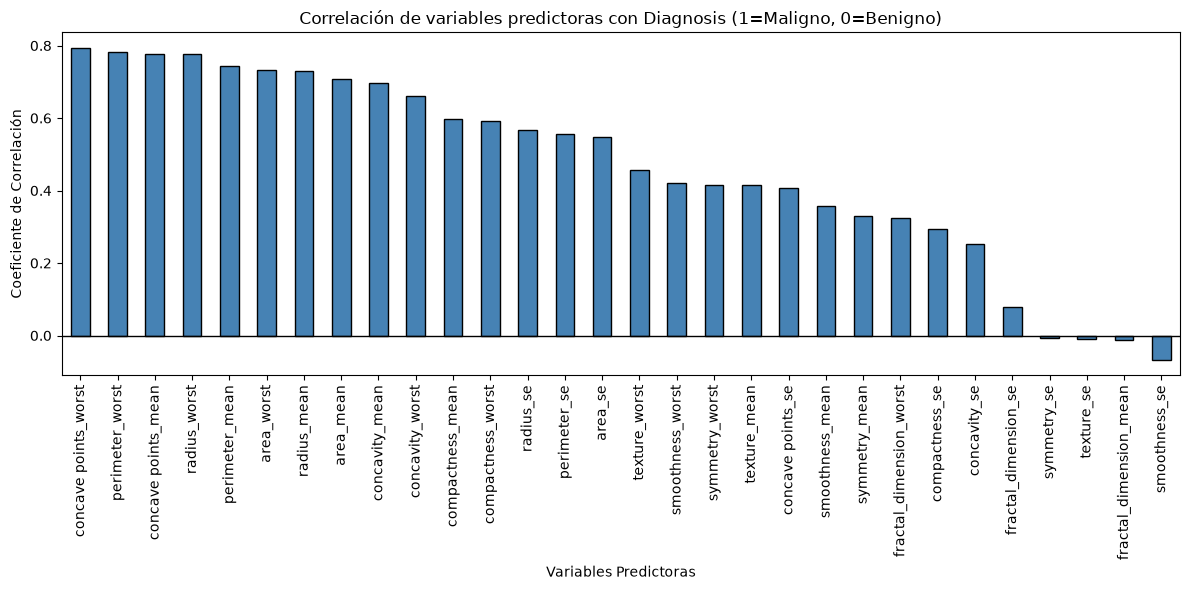

In [14]:
# 5.Visualización gráfica de la correlación de las variables predictoras
plt.figure(figsize=(12, 6))
# Se excluye la propia variable 'diagnosis' (que tendría correlación 1.0) para el gráfico
correlacion_diagnosis.drop('diagnosis').plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Correlación de variables predictoras con Diagnosis (1=Maligno, 0=Benigno)')
plt.ylabel('Coeficiente de Correlación')
plt.xlabel('Variables Predictoras')
plt.xticks(rotation=90)
plt.axhline(0, color='black', linewidth=1)
plt.tight_layout()
plt.show()

Se logra observar que la gran mayoria de columnas tienen correlacion con el target, pero hay algunas que tienen negativa, igualemnte son muy pocas para influir sinificaticamente, ademas el dataset presenta indicios de multicolinealidad debido a los multiples variaciobles que miden la celula


Matriz de Correlación:
                         diagnosis  radius_mean  texture_mean  perimeter_mean  \
diagnosis                 1.000000     0.730029      0.415185        0.742636   
radius_mean               0.730029     1.000000      0.323782        0.997855   
texture_mean              0.415185     0.323782      1.000000        0.329533   
perimeter_mean            0.742636     0.997855      0.329533        1.000000   
area_mean                 0.708984     0.987357      0.321086        0.986507   
smoothness_mean           0.358560     0.170581     -0.023389        0.207278   
compactness_mean          0.596534     0.506124      0.236702        0.556936   
concavity_mean            0.696360     0.676764      0.302418        0.716136   
concave points_mean       0.776614     0.822529      0.293464        0.850977   
symmetry_mean             0.330499     0.147741      0.071401        0.183027   
fractal_dimension_mean   -0.012838    -0.311631     -0.076437       -0.261477   
radi

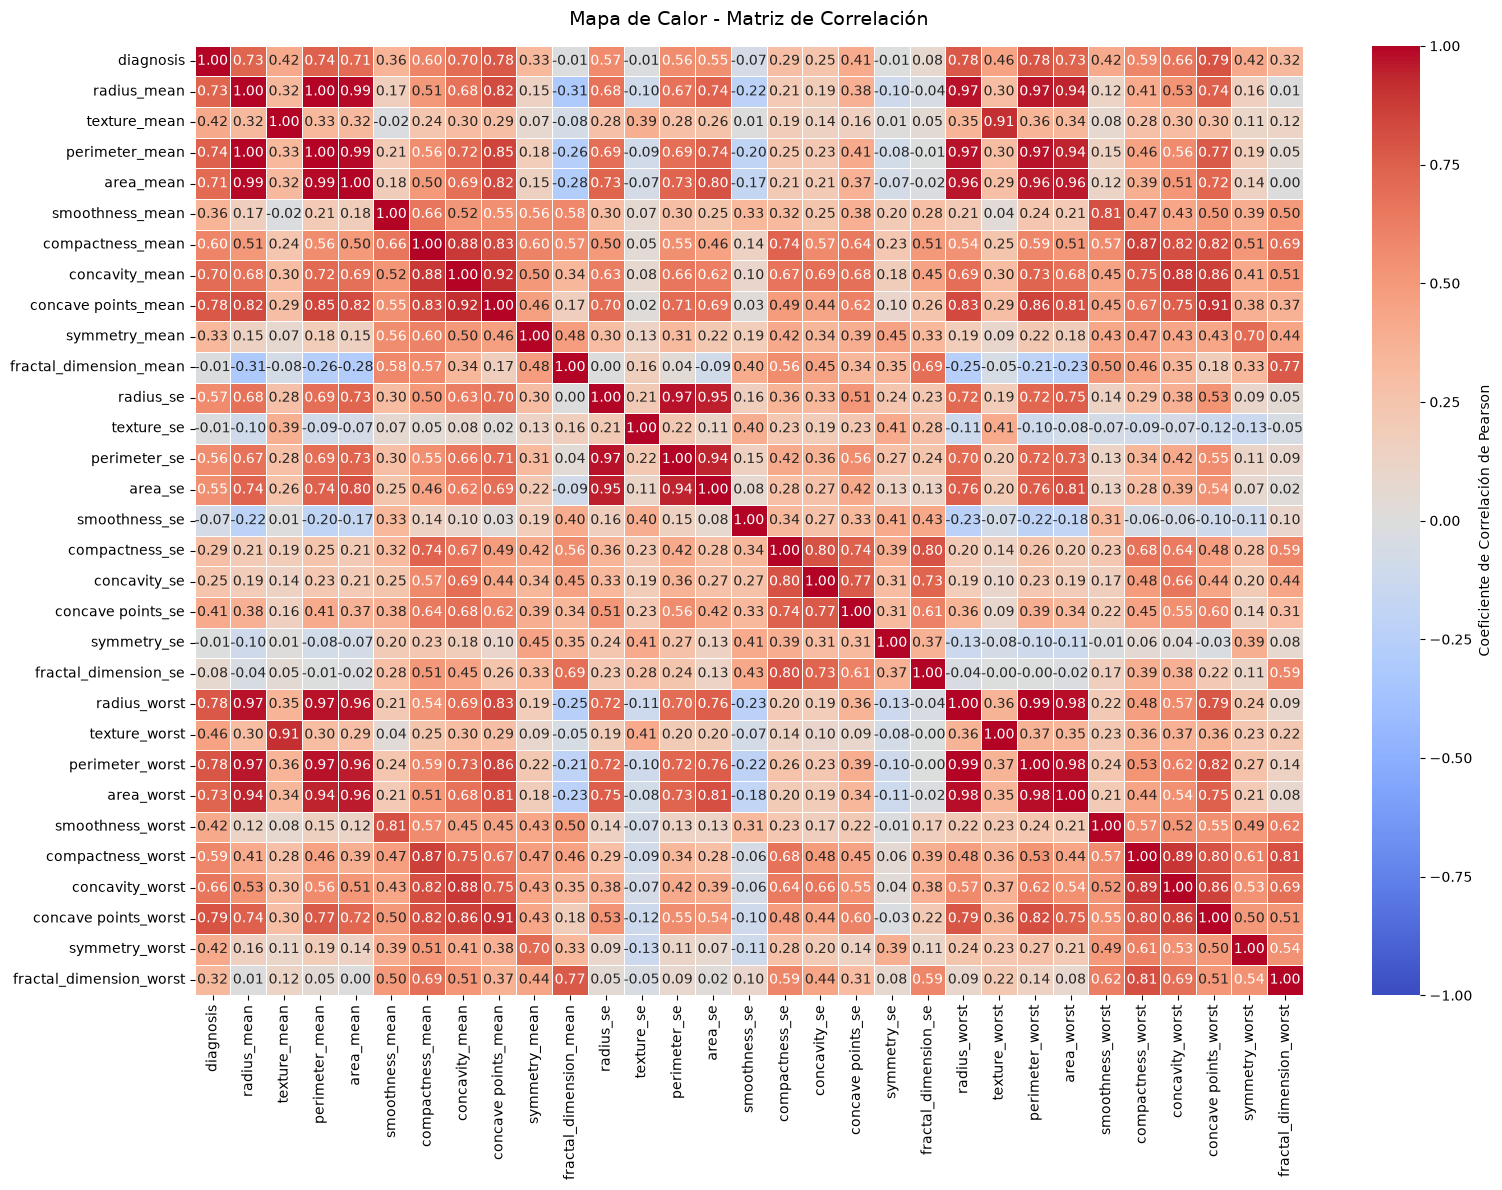

In [15]:
matriz_correlacion = df_breast_copia.corr()

# Mostramos la matriz en texto (opcional)
print("\nMatriz de Correlación:")
print(matriz_correlacion)

# Generamos el mapa de calor (Heatmap)
plt.figure(figsize=(16, 12))
sns.heatmap(
    matriz_correlacion, 
    annot=True,          # Muestra el valor numérico en cada celda
    fmt=".2f",           # Limita a 2 decimales para que sea legible
    cmap='coolwarm',     # Gradiente de azul (negativo) a rojo (positivo)
    vmin=-1, vmax=1,     # Escala de correlación estandarizada
    linewidths=0.5, 
    cbar_kws={'label': 'Coeficiente de Correlación de Pearson'}
)

plt.title('Mapa de Calor - Matriz de Correlación', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

Se logra ver de que hay una cantidad considerable variables altamente relacionadas. Esto termina generando un problema de multicolinealidad

## Analisis de multicolinealidad

"La multicolinealidad es un fenómeno estadístico que ocurre cuando dos o más variables independientes en un modelo de regresión están altamente correlacionadas, lo que significa que una puede predecirse linealmente a partir de las demás con un grado sustancial de precisión."

En este caso se puede visualizar en las columas que guardan distintas mediciones tinene informacion relacionada, especificamente el area, perimetro y rango, que son medidas del espacio que usa un objeto,

### Uso de area como unico paramatro de medicion

Para prevenir el fenomeno anteriormente descrito, se ocupara solamente la variables que gaurden el area, esto debido a que una de las princpales formas de detecar si el tumor en maligno o el paciente presentara cancer.

El área tambien mide la totalidad del espacio bidimensional que ocupa la masa de la célula. Cuando una célula muta y comienza a generar un bulto anormal, es todo su cuerpo el que exige más espacio físico. El área es capaz de capturar esa magnitud total, entregando un número que representa fielmente el tamaño completo de la anomalía.

Procedemos a eleminar las columnas que no sean el area.

In [16]:
# Identificamos todas las columnas que contengan 'radius' o 'perimeter' en su nombre
columnas_geometria_basica = [col for col in df_breast_copia.columns if 'radius' in col or 'perimeter' in col]

# Eliminamos estas columnas del DataFrame filtrado (el que ya tenía solo _mean y _worst)
df_limpio = df_breast_copia.drop(columns=columnas_geometria_basica)

print("Columnas eliminadas (Radio y Perímetro):")
for col in columnas_geometria_basica:
    print(f" - {col}")

print(f"\nCantidad de columnas restantes listas para el VIF: {df_limpio.shape[1]}")

Columnas eliminadas (Radio y Perímetro):
 - radius_mean
 - perimeter_mean
 - radius_se
 - perimeter_se
 - radius_worst
 - perimeter_worst

Cantidad de columnas restantes listas para el VIF: 25


## Justificacion de mantener variables "worst" y "se"

El desarrollo de este modelo predictivo conserva las variables correspondientes al error estándar y a los peores valores debido a que capturan comportamientos biológicos cruciales que los promedios generales (_mean) suelen diluir.

Error Estándar (_se) para detectar la heterogeneidad tumoral: El error estándar cuantifica el nivel de desigualdad y caos dentro de la misma muestra de tejido del paciente. Un tejido benigno presenta células uniformes y ordenadas, lo que resulta en una variación cercana a cero. Por el contrario, el desarrollo maligno es inherentemente desordenado. En otras entre mayot el error estandar 

Peor Valor (_worst) para aislar anomalías extremas: Esta métrica corresponde a la media de los tres valores más grandes encontrados para cada característica en la imagen digitalizada de la mama. Su función principal es exponer la gravedad actual y localizada del tejido. Al enfocarse exclusivamente en las células más irregulares de la muestra. En otras palabras esta variable nos muestra que tan grave esta el paciente

## Inflacion de varianza (VIF)

"Un factor de inflación de varianza (VIF) proporciona una medida de multicolinealidad entre las variables independientes en un modelo de regresión múltiple. Mide cuánto se infla la varianza de una estimación de coeficiente debido a la multicolinealidad. "

In [17]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Aislar únicamente las variables predictoras (excluimos el target 'diagnosis')
# Eliminamos temporalmente los valores nulos si los hay, ya que VIF requiere datos completos
X = df_breast.drop(columns=['diagnosis']).dropna()

# 2. Crear un DataFrame vacío para estructurar los resultados en una tabla
vif_data = pd.DataFrame()
vif_data["Variable Predictora"] = X.columns

# 3. Calcular el VIF iterando por el índice de cada columna de la matriz de características
# Al usar X.values, pasamos los datos como un arreglo matemático puro
vif_data["Valor VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# 4. Ordenar los resultados de mayor a menor para detectar los casos más graves
vif_data = vif_data.sort_values(by="Valor VIF", ascending=False).reset_index(drop=True)

print("Factor de Inflación de Varianza (VIF) Con el dataset original:")
print(vif_data)

Factor de Inflación de Varianza (VIF) Con el dataset original:
        Variable Predictora    Valor VIF
0               radius_mean  3806.464754
1            perimeter_mean  3786.400488
2              radius_worst   799.418629
3           perimeter_worst   405.023630
4                 area_mean   347.968386
5                area_worst   337.319359
6                 radius_se    75.653561
7            concavity_mean    70.785037
8              perimeter_se    70.363596
9       concave points_mean    60.060406
10         compactness_mean    50.527114
11                  area_se    41.688437
12        compactness_worst    37.010829
13     concave points_worst    36.791231
14          concavity_worst    31.971022
15  fractal_dimension_worst    18.863976
16            texture_worst    18.570023
17   fractal_dimension_mean    15.759755
18             concavity_se    15.699567
19           compactness_se    15.378147
20             texture_mean    11.901803
21        concave points_se    11.5

Se logra ver de que antes del tratemiento presenta bastante variacion. Osea que quiere decir que hay variables que terminan siendo altamente redundantes en la correlacion entre variables

In [18]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Aislar únicamente las variables predictoras (excluimos el target 'diagnosis')
# Eliminamos temporalmente los valores nulos si los hay, ya que VIF requiere datos completos
X = df_limpio.drop(columns=['diagnosis']).dropna()

# 2. Crear un DataFrame vacío para estructurar los resultados en una tabla
vif_data = pd.DataFrame()
vif_data["Variable Predictora"] = X.columns

# 3. Calcular el VIF iterando por el índice de cada columna de la matriz de características
# Al usar X.values, pasamos los datos como un arreglo matemático puro
vif_data["Valor VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# 4. Ordenar los resultados de mayor a menor para detectar los casos más graves
vif_data = vif_data.sort_values(by="Valor VIF", ascending=False).reset_index(drop=True)

print("Factor de Inflación de Varianza (VIF) Con el dataset limpio:")
print(vif_data)

Factor de Inflación de Varianza (VIF) Con el dataset limpio:
        Variable Predictora  Valor VIF
0            concavity_mean  63.714355
1       concave points_mean  57.236099
2         compactness_worst  34.168224
3      concave points_worst  33.579946
4           concavity_worst  31.519447
5          compactness_mean  28.375536
6                 area_mean  25.140127
7                area_worst  21.095159
8   fractal_dimension_worst  18.230336
9             texture_worst  17.689321
10           compactness_se  14.809190
11             concavity_se  14.312045
12   fractal_dimension_mean  12.286236
13             texture_mean  11.429871
14         smoothness_worst  10.606075
15        concave points_se   9.324117
16           symmetry_worst   9.054238
17     fractal_dimension_se   8.824678
18          smoothness_mean   7.721225
19                  area_se   5.088292
20              symmetry_se   4.905420
21            symmetry_mean   4.050443
22               texture_se   3.942788
23 

Los numeros han disminuido signifivamente , esto ayudara a prevenir el fenomeno de la multicolinelidad y mejorar el rendimiento del modelo

# Comparacion de los data sets (limpio/original)

Verificamos filas eliminadas

In [19]:
print(f"Cantidad de filas original {df_breast.shape[1]}")
print(f"Cantidad de filas en el dataset limpio {df_limpio.shape[1]}")
print(f"Cantidad de filas eliminadas {df_breast.shape[1] - df_limpio.shape[1]}")

Cantidad de filas original 32
Cantidad de filas en el dataset limpio 25
Cantidad de filas eliminadas 7


# Particionamiento entrenamiento y validacion

Para entrenar el modelo separaremos los datos, como estandar se tiende a usar un 20 por ciento de los datos pra las pruebas. Con Random State hacemos que los datos vayan cambiando, pero el 42 siempre sera la misma proporcion. Con stratify hacemos que los datos mantengan la misma proporcion en la varibale target y no se dispersen de manera aleatoria

In [21]:

X = df_limpio.drop(columns=['diagnosis'])
y = df_limpio['diagnosis']

# 2. Partición: 80% entrenamiento y 20% prueba con estratificación (mantiene proporciones de clases)
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, #Tamanio de la prueba (20%)
    random_state=42, 
    stratify=y
)

Procedemos a mostrar como quedaron las pruebas y test de X y Y 

In [28]:

print(f"Cantidad de registros para X_train : {len(X_train)}")
X_train.head()

Cantidad de registros para X_train : 455


,texture_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,texture_se,area_se,...,symmetry_se,fractal_dimension_se,texture_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
10,23.24,797.8,0.08206,0.06669,0.03299,0.03323,0.1528,0.05697,1.1870,40.51,...,0.01460,0.003042,33.88,1150.0,0.11810,0.1551,0.1459,0.09975,0.2948,0.08452
170,12.39,464.1,0.10280,0.06981,0.03987,0.03700,0.1959,0.05955,0.6656,17.43,...,0.01924,0.002248,15.64,549.1,0.13850,0.1266,0.1242,0.09391,0.2827,0.06771
407,21.37,514.5,0.07551,0.08316,0.06126,0.01867,0.1580,0.06114,1.7980,41.24,...,0.02669,0.007731,27.01,645.8,0.09402,0.1936,0.1838,0.05601,0.2488,0.08151
430,22.53,685.0,0.09947,0.22250,0.27330,0.09711,0.2041,0.06898,0.8749,24.19,...,0.01499,0.005784,27.57,832.7,0.14190,0.7090,0.9019,0.24750,0.2866,0.11550
27,20.25,1094.0,0.09440,0.10660,0.14900,0.07731,0.1697,0.05699,1.8490,93.54,...,0.02293,0.004217,27.26,1403.0,0.13380,0.2117,0.3446,0.14900,0.2341,0.07421


In [27]:

print(f"Cantidad de registros para X_test : {len(X_test)}")
X_test.head()

Cantidad de registros para X_test : 114


,texture_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,texture_se,area_se,...,symmetry_se,fractal_dimension_se,texture_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
120,10.82,403.3,0.09373,0.06685,0.03512,0.02623,0.1667,0.06113,0.4607,10.50,...,0.01344,0.002206,15.97,510.5,0.1548,0.2390,0.21020,0.08958,0.3016,0.08523
250,23.56,1364.0,0.10070,0.16060,0.27120,0.13100,0.2205,0.05898,0.8208,137.90,...,0.02401,0.005002,27.00,2010.0,0.1211,0.3172,0.69910,0.21050,0.3126,0.07849
375,16.07,788.5,0.09880,0.14380,0.06651,0.05397,0.1990,0.06572,0.4890,14.91,...,0.01934,0.003696,19.14,861.5,0.1235,0.2550,0.21140,0.12510,0.3153,0.08960
99,19.77,642.5,0.09752,0.11410,0.09388,0.05839,0.1879,0.06390,1.8510,26.85,...,0.01462,0.004452,30.86,826.4,0.1431,0.3026,0.31940,0.15650,0.2718,0.09353
455,30.72,557.2,0.09245,0.07426,0.02819,0.03264,0.1375,0.06016,1.9240,28.93,...,0.01564,0.002985,41.61,705.6,0.1172,0.1421,0.07003,0.07763,0.2196,0.07675


Ahora procedemos a ver como estan los datos con Y.
Y_test : 

In [33]:
print(f"Catidad de registros para y_test {len(y_test)}")
y_test.head()

Catidad de registros para y_test 114


120    0
250    1
375    0
99     1
455    0
Name: diagnosis, dtype: int64

In [37]:
print(f"Cantidad de registron para y_train: {len(y_train)}")
y_train.head()

Cantidad de registron para y_train: 455


10     1
170    0
407    0
430    1
27     1
Name: diagnosis, dtype: int64

Se a logrado visualizar y comprobar que los datos han sido extosamente separados para entrenmiento y prueba

# Fuentes

https://medium.com/@azizozmen/understanding-multicollinearity-its-impact-on-data-analysis-and-machine-learning-94da6620569e